**PHÂN TÍCH PHƯƠNG SAI HAI NHÂN TỐ (TWO-WAY ANOVA)**

Trong phần này, chúng ta sẽ mở rộng bài toán phân tích từ một nhân tố lên hai nhân tố để xem xét sức mạnh tác động đồng thời của **Nhà sản xuất (Manufacturer)** và **Loại thiết bị (Device Type)** lên mức tiêu thụ điện năng của GPU.

**1. Mục tiêu và Giả thuyết nghiên cứu**
Mục tiêu là xác định xem liệu sự khác biệt về điện năng **(Max_Power)** có phụ thuộc vào việc GPU đó thuộc hãng nào, là dòng cho Laptop hay Desktop, và quan trọng nhất là liệu có sự tương tác giữa hai yếu tố này hay không.
**Các cặp giả thuyết ($H_0$):** 
 1. **Hãng sản xuất:** Không có sự khác biệt về điện năng trung bình giữa các hãng (Nvidia, AMD, Intel).
 2. **Loại thiết bị:**  Không có sự khác biệt về điện năng trung bình giữa dòng Laptop và Desktop.
 3. **Sự tương tác:** Hiệu ứng của loại thiết bị lên điện năng không phụ thuộc vào hãng sản xuất.

In [35]:
# 1. Khai báo các thư viện cần thiết
library(dplyr)    # lọc và xử lý dữ liệu
library(ggplot2)  # vẽ biểu đồ
library(car)      # kiểm định Levene 
# Cấu hình hiển thị số thưa và rõ ràng
options(scipen = 999)
options(width = 120)  

**2. Tiền xử lý dữ liệu cho ANOVA 2 nhân tố**
Dữ liệu cần được làm sạch để đảm bảo các "ô" tổ hợp (Cell) có đủ số lượng mẫu thực nghiệm. Chúng ta loại bỏ hãng **ATI** do thiếu mẫu dòng Laptop và thực hiện ép kiểu **Factor** để đảm bảo tính toán chính xác cho các hàm hậu định.

In [36]:
# 2.1. Đọc dữ liệu
df <- read.csv("/kaggle/input/datasets/tunlnguynanh/gpu-ready-for-models/gpu_ready_for_models.csv")

# 2.2. Lọc dữ liệu cho mô hình 2 nhân tố
df_2way <- df %>%
  filter(Manufacturer != "ATI") %>% 
  group_by(Manufacturer, Notebook_GPU) %>%
  filter(n() > 20) %>%
  ungroup() %>%
  mutate(
    Manufacturer = as.factor(Manufacturer),
    Notebook_GPU = as.factor(ifelse(as.logical(Notebook_GPU), "Laptop", "Desktop"))
  )

# Kiểm tra bảng tần suất các nhóm tổ hợp
cat("--- BẢNG TẦN SUẤT CÁC NHÓM TỔ HỢP ---\n")
print(table(df_2way$Manufacturer, df_2way$Notebook_GPU))

--- BẢNG TẦN SUẤT CÁC NHÓM TỔ HỢP ---
        
         Desktop Laptop
  AMD        991    237
  Intel       88    134
  Nvidia    1373    271


**3. Trực quan hóa dữ liệu và Tương tác**
Sử dụng Interaction Plot để quan sát sự biến thiên của biến phụ thuộc.

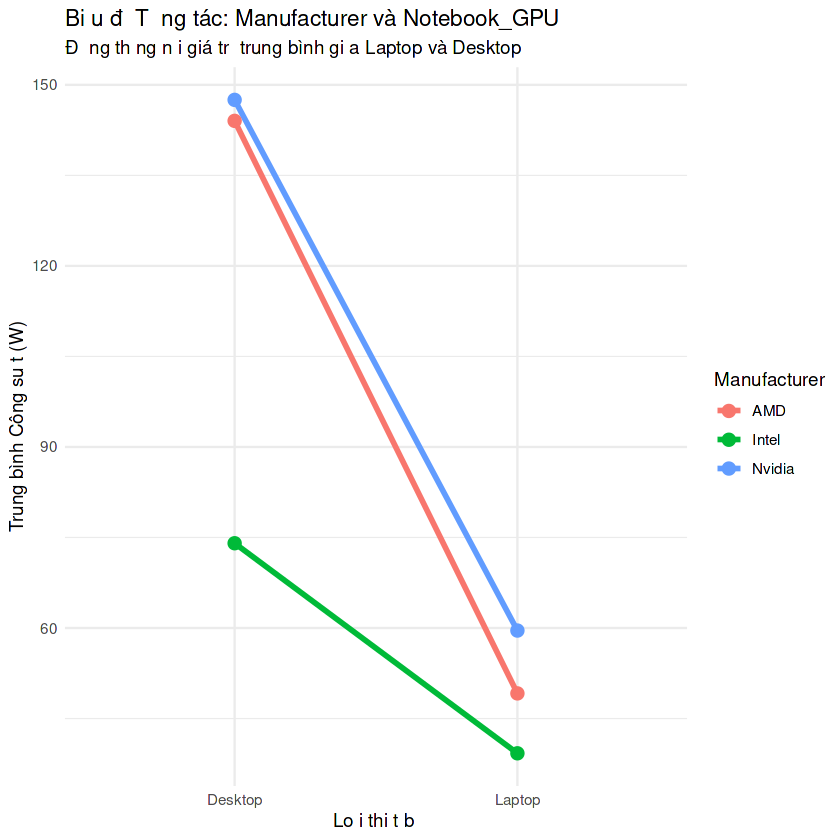

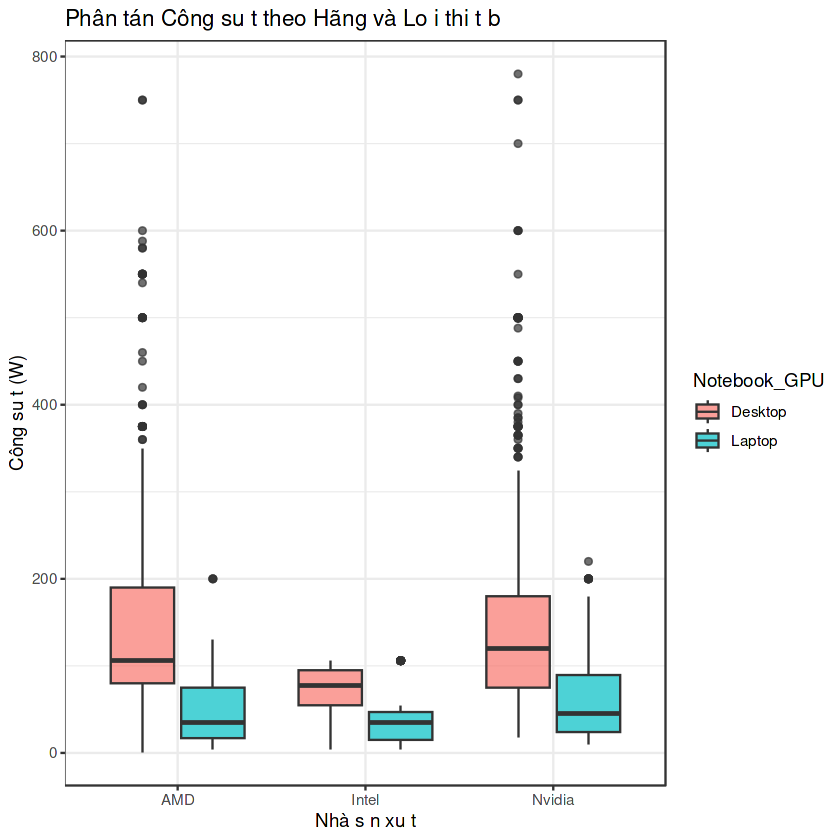

In [37]:
# 3.1. Biểu đồ tương tác (Interaction Plot) 
ggplot(df_2way, aes(x = Notebook_GPU, y = Max_Power, color = Manufacturer, group = Manufacturer)) +
  stat_summary(fun = mean, geom = "line", linewidth = 1.2, aes(group = Manufacturer)) + 
  stat_summary(fun = mean, geom = "point", size = 3) +
  labs(title = "Biểu đồ Tương tác: Manufacturer và Notebook_GPU",
       subtitle = "Đường thẳng nối giá trị trung bình giữa Laptop và Desktop",
       x = "Loại thiết bị",
       y = "Trung bình Công suất (W)") +
  theme_minimal()

# 3.2. Biểu đồ Boxplot để xem sự phân tán
ggplot(df_2way, aes(x = Manufacturer, y = Max_Power, fill = Notebook_GPU)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Phân tán Công suất theo Hãng và Loại thiết bị",
       x = "Nhà sản xuất", y = "Công suất (W)") +
  theme_bw()

**Nhận xét biểu đồ:**

Nếu các đường thẳng đại diện cho các hãng (Nvidia, AMD, Intel) song song với nhau, điều đó cho thấy không có sự tương tác.
Nếu các đường thẳng cắt nhau hoặc có độ dốc khác nhau, điều đó minh chứng cho sự tương tác: ví dụ, một hãng có thể tối ưu điện năng cho Laptop tốt hơn hẳn các hãng còn lại.

**4. Kiểm tra các giả định của mô hình**
Trước khi kết luận từ bảng ANOVA, ta cần kiểm tra các điều kiện tiên quyết:
**4.1. Tính đồng nhất của phương sai (Homogeneity of Variance)**
Sử dụng kiểm định **Levene’s Test** trên toàn bộ các tổ hợp nhóm.
 1. $H_0$: Phương sai các nhóm bằng nhau.
 2. Nếu $p-value < 0.05$, ta cần thận trọng hoặc sử dụng các biến đổi dữ liệu vì vi phạm giả định này.
**4.2. Tính phân phối chuẩn (Normality)**
Sử dụng đồ thị **Q-Q Plot** cho phần dư (Residuals) của mô hình. Các điểm dữ liệu nằm sát đường chéo sẽ xác nhận tính phân phối chuẩn của dữ liệu.

--- 1. KIỂM ĐỊNH LEVENE ---
Levene's Test for Homogeneity of Variance (center = median)
        Df F value                Pr(>F)    
group    5  31.986 < 0.00000000000000022 ***
      3088                                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- 2. ĐỒ THỊ Q-Q PLOT ---


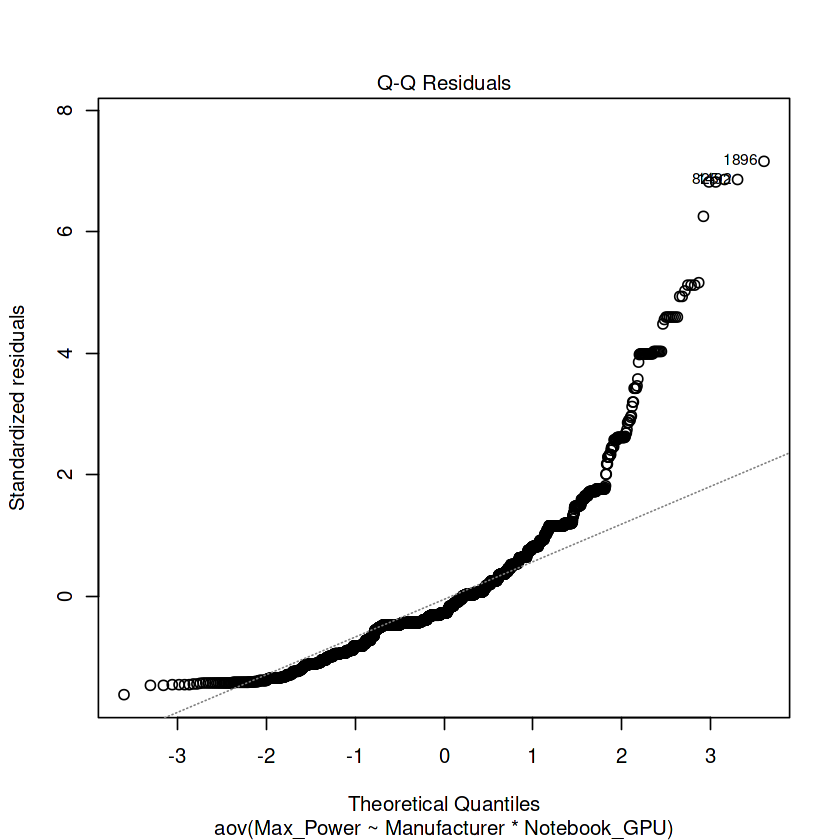

In [38]:
# 4.1. Khởi tạo mô hình (Xét cả hiệu ứng chính và tương tác)
model_2way <- aov(Max_Power ~ Manufacturer * Notebook_GPU, data = df_2way)

# 4.2. Kiểm định Levene (Đồng nhất phương sai)
cat("--- 1. KIỂM ĐỊNH LEVENE ---\n")
print(leveneTest(Max_Power ~ Manufacturer * Notebook_GPU, data = df_2way))

# 4.3. Đồ thị Q-Q Plot
cat("\n--- 2. ĐỒ THỊ Q-Q PLOT ---\n")
plot(model_2way, which = 2)

In [39]:
# 5. Bảng kết quả ANOVA chính thức
cat("\n--- 3. BẢNG KẾT QUẢ ANOVA 2 NHÂN TỐ ---\n")
print(summary(model_2way))


--- 3. BẢNG KẾT QUẢ ANOVA 2 NHÂN TỐ ---
                            Df   Sum Sq Mean Sq F value               Pr(>F)    
Manufacturer                 2  1254869  627434   80.39 < 0.0000000000000002 ***
Notebook_GPU                 1  3381461 3381461  433.26 < 0.0000000000000002 ***
Manufacturer:Notebook_GPU    2   154377   77189    9.89            0.0000523 ***
Residuals                 3088 24100894    7805                                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


**5. Kết quả mô hình ANOVA 2 nhân tố**
Chúng ta đánh giá sức mạnh tác động thông qua bảng ANOVA với công thức: ***Max_Power ~ Manufacturer * Device_Type***.

Giải thích kết quả:
**1. Manufacturer:** Đánh giá sự khác biệt thuần túy giữa các hãng.
**2. Device_Type:** Đánh giá sự khác biệt thuần túy giữa Laptop và Desktop.
**3. Manufacturer:Device_Type:** Nếu $p-value < 0.05$, ta kết luận có Sự tương tác. Đây là bằng chứng cho thấy một hãng cụ thể (ví dụ Nvidia) có thể có mức giảm điện năng cho Laptop vượt trội hơn so với các hãng khác.

**6. Kiểm định hậu định (Tukey HSD)**
Do mô hình có nhiều cặp tổ hợp, kiểm định Tukey HSD được thực hiện để xác định cụ thể cặp nhóm nào có sự khác biệt về mặt thống kê (ví dụ: so sánh giữa Nvidia-Laptop và AMD-Laptop).

--- 4. KIỂM ĐỊNH HẬU ĐỊNH TUKEY HSD ---
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Max_Power ~ Manufacturer * Notebook_GPU, data = df_2way)

$Manufacturer
                   diff        lwr       upr     p adj
Intel-AMD    -72.689534 -87.797231 -57.58184 0.0000000
Nvidia-AMD     7.292678  -0.520578  15.10593 0.0732724
Nvidia-Intel  79.982212  65.170053  94.79437 0.0000000

$Notebook_GPU
                    diff     lwr       upr p adj
Laptop-Desktop -78.41358 -86.093 -70.73415     0

$`Manufacturer:Notebook_GPU`
                                    diff         lwr         upr     p adj
Intel:Desktop-AMD:Desktop     -69.989863  -98.010872 -41.9688544 0.0000000
Nvidia:Desktop-AMD:Desktop      3.478156   -7.022171  13.9784839 0.9348464
AMD:Laptop-AMD:Desktop        -94.870761 -113.086189 -76.6553324 0.0000000
Intel:Laptop-AMD:Desktop     -104.796512 -127.983175 -81.6098492 0.0000000
Nvidia:Laptop-AMD:Desktop     -84.455982 -101.724673 -6

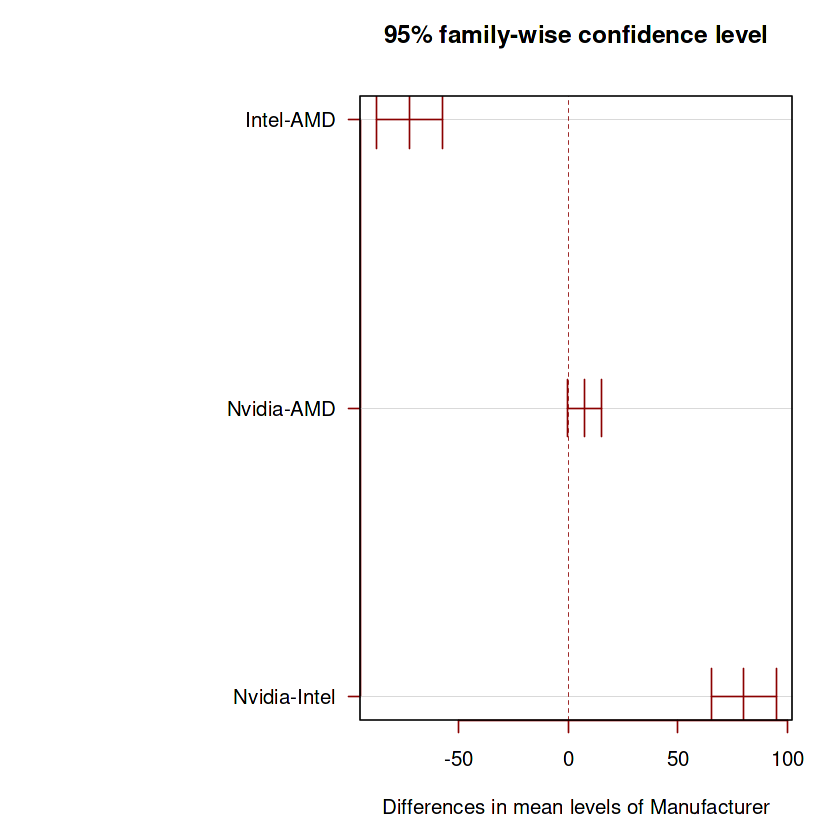

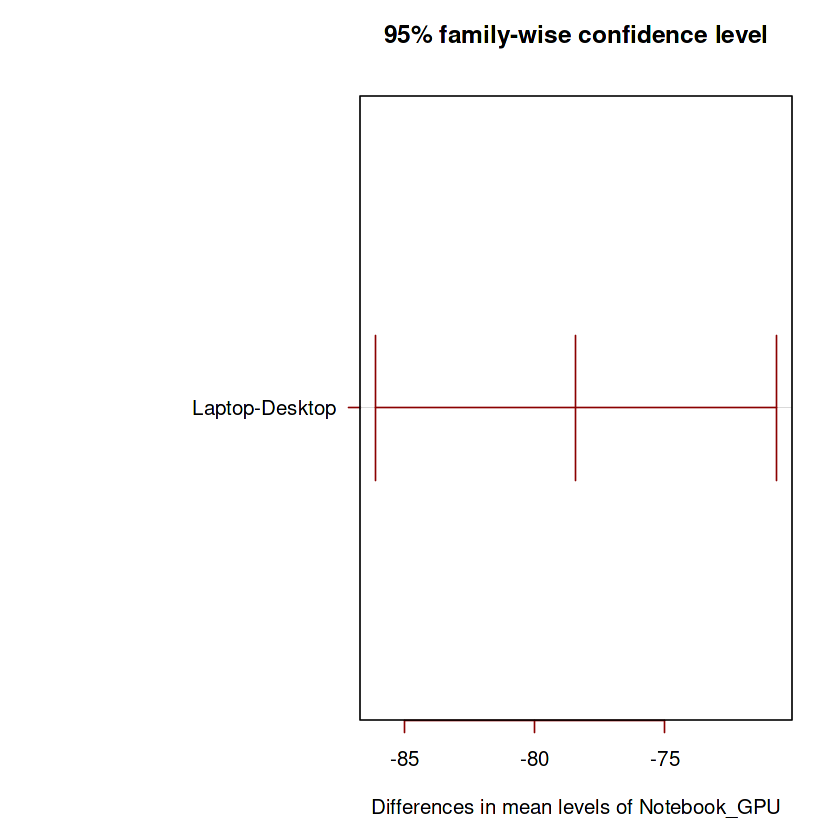

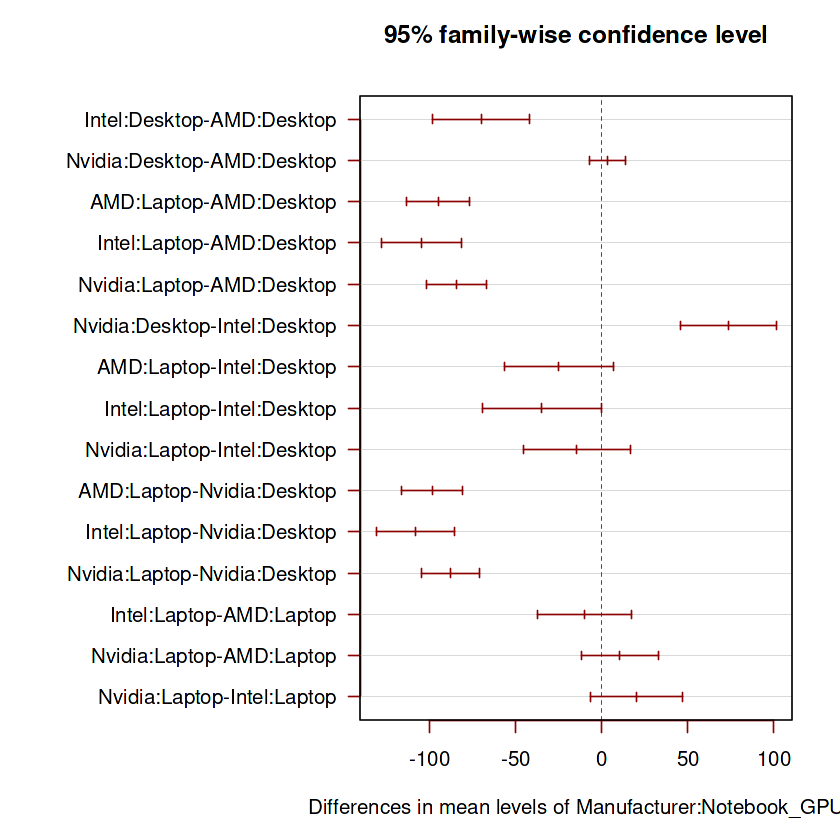

In [40]:
# 5. So sánh cặp chi tiết
cat("--- 4. KIỂM ĐỊNH HẬU ĐỊNH TUKEY HSD ---\n")
tukey_2way <- TukeyHSD(model_2way)
print(tukey_2way)
# Vẽ biểu đồ Tukey
par(mar=c(5, 15, 4, 2)) 
plot(tukey_2way, las = 1, col = "darkred")

**Kết luận:** Dựa trên các chỉ số $p-adj$ trong bảng Tukey, chúng ta xác định được các nhóm ưu thế về mặt tiêu thụ điện năng và đưa ra đánh giá cuối cùng về sự tối ưu hóa công nghệ của từng nhà sản xuất trên các nền tảng thiết bị khác nhau.